In [1]:
# functional score curves for each K3 condition

In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# figure save directory
save_dir = "../../img/score-curves"
os.makedirs(save_dir, exist_ok=True)

In [12]:
input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

In [16]:
df.head()

,k3,pkr,auc_mean,auc_std,auc_sem,pkr_bc_nunique,0hr_total_reads,site,pkr_regions,pkr_type,...,wt_cat,var_cat,isr_kinase_conservation,elde_primate_positive_selection,vertebrate_positive_selection,pkr_conservation,jaquet_primate_positive_selection,vert_sele_analysis,elde_primate_sele_analysis,jaquet_primate_sele_analysis
0,K3Δ58,PKR-A488D,4.426750,1.587491,0.440291,13,3187.0,488.0,Region 4,Variant,...,Non-Polar,Negative Charge,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN
1,K3Δ58,PKR-A488G,4.936558,1.751800,0.468188,14,3970.0,488.0,Region 4,Variant,...,Non-Polar,Unique,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN
2,K3Δ58,PKR-A488P,-6.406692,0.347793,0.115931,9,3073.0,488.0,Region 4,Variant,...,Non-Polar,Unique,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN
3,K3Δ58,PKR-A488S,3.914160,1.371766,0.314705,19,4567.0,488.0,Region 4,Variant,...,Non-Polar,Polar-Neutral,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN
4,K3Δ58,PKR-A488T,3.998408,1.929033,0.498074,15,3644.0,488.0,Region 4,Variant,...,Non-Polar,Polar-Neutral,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN


/tmp/ipykernel_205704/1737503447.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.query('pkr_type == "Variant"', inplace=True)
/tmp/ipykernel_205704/1737503447.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.sort_values(by=['auc_mean'], ascending=False, inplace=True)


Scatter Plot with Standard Deviation Bars


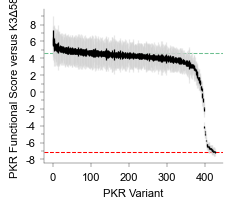

Scatter Plot with Standard Deviation Bars


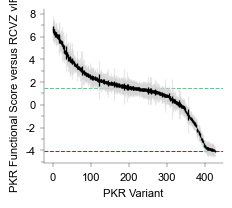

Scatter Plot with Standard Deviation Bars


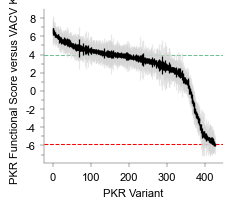

Scatter Plot with Standard Deviation Bars


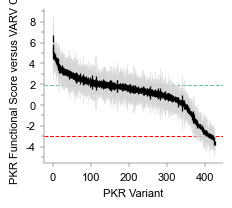

Scatter Plot with Standard Deviation Bars


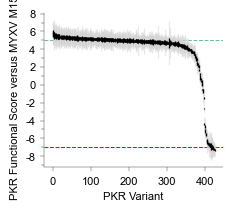

Scatter Plot with Standard Deviation Bars


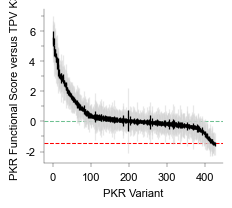

In [17]:
# small plots
k3_conditions = ['K3Δ58', 'RCVZ vIF2α', 'VACV K3', 'VARV C3','MYXV M156R','TPV K3']

for k3 in k3_conditions:
    # plot parameters
    width_in = 2.3
    height_in = 2
    font_size = 8
    font = 'Arial'
    stroke = .25
    tick_len = 3
    alpha_val = .2
    marker_diameter = 3 # 3
    #ymin = -5
    #ymax=5.9

    font = {'family': font, 'size': font_size}
    plt.rc('font', **font)
    plt.rc('lines', linewidth=stroke)
    plt.figure(figsize=(width_in, height_in)) # save size

    temp_df = df.query('k3 == @k3')

    hline_wt = temp_df.query('pkr_type == "WT"')['auc_mean'].values[0]
    hline_non = temp_df.query('pkr_type == "Nonsense"')['auc_mean'].values[0]

    temp_df.query('pkr_type == "Variant"', inplace=True)
    temp_df.sort_values(by=['auc_mean'], ascending=False, inplace=True)
    #temp_df.sort_values(by=, ascending=True, inplace=True)
    temp_df.reset_index(drop=True, inplace=True)
    
    # Plot elements
    for i, row in temp_df.query('pkr_type == "Variant"').iterrows():
        #plt.errorbar(i, row['auc_mean'], yerr=row['auc_std'], fmt='-', color='gray', capsize=0, alpha=0.5, zorder=1)
        plt.errorbar(i, row['auc_mean'], yerr=row['auc_std'], fmt='-', color='lightgray', capsize=0, zorder=1, alpha=.5, elinewidth=.9)
        #plt.errorbar(i, row['auc_mean'], yerr=row['auc_sem'], fmt='-', color='black', capsize=0, alpha=1, zorder=2)
        plt.errorbar(i, row['auc_mean'], yerr=row['auc_sem'], fmt='-', c='black', capsize=0, zorder=2, elinewidth=.9)
        #plt.scatter(i,row['auc_mean'], c=row['region_color'], alpha=1, zorder=3, s=2)
    
    # y tick limits
    if k3 == "K3L-Null":
        plt.ylim(-8, 8)
    elif k3 == "K3L-WT":
        plt.ylim(-6, 10)
    elif k3 == "K3L-H47R":
        plt.ylim(-4, 12)

    # modify plot spines
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)

    # Set major ticks at even numbers and label as integers
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(2))
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

    # Show minor ticks for every integer
    plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))
    
    # Set major tick length
    ax.tick_params(axis='both', direction='out', length=tick_len, width=stroke)
    plt.gca().yaxis.set_tick_params(width=stroke, which='both', direction='out')

    # pkr wt
    plt.axhline(y=hline_wt, color='#6dc091', linestyle='--', linewidth=.75, zorder=0)

    # pkr nonsense  
    plt.axhline(y=hline_non, color='red', linestyle='--', linewidth=.75, zorder=0)
    
    # Add labels and title
    plt.xlabel('PKR Variant')
    plt.ylabel(f'PKR Functional Score versus {k3}')
    print(f'Scatter Plot with Standard Deviation Bars')
    
    # Show plot
    plt.show()

    fig = ax.get_figure()

    # save plot
    plot_name = f'small-score-curve_{k3}.svg'
    output_file = os.path.join(save_dir, plot_name)
    fig.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

/tmp/ipykernel_205704/1454365111.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.query('pkr_type == "Variant"', inplace=True)
/tmp/ipykernel_205704/1454365111.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.sort_values(by=['auc_mean'], ascending=False, inplace=True)


Scatter Plot with Standard Deviation Bars


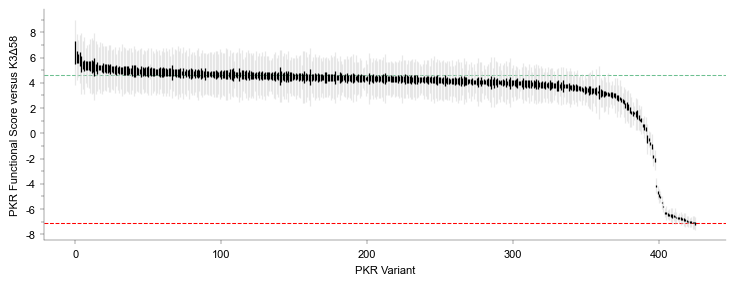

Scatter Plot with Standard Deviation Bars


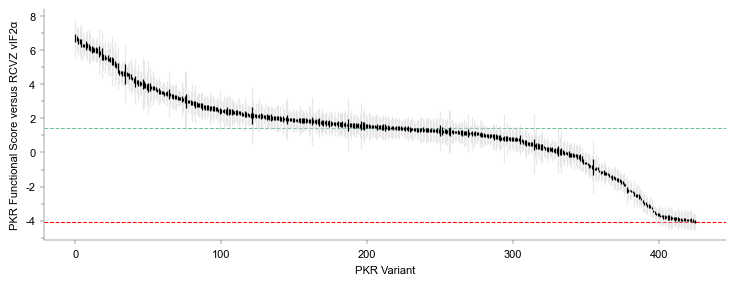

Scatter Plot with Standard Deviation Bars


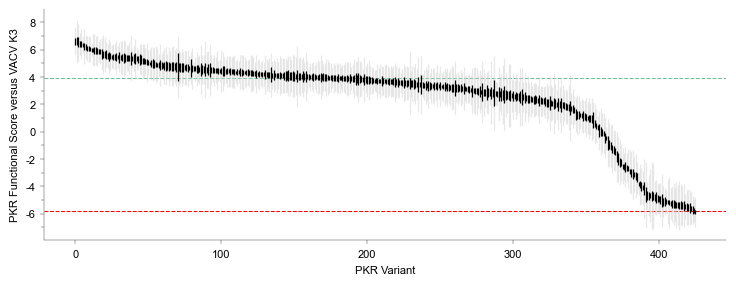

Scatter Plot with Standard Deviation Bars


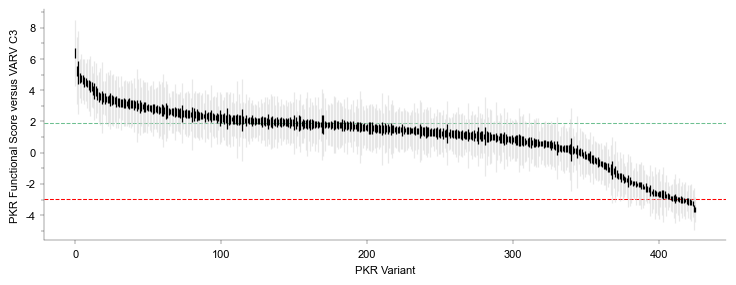

Scatter Plot with Standard Deviation Bars


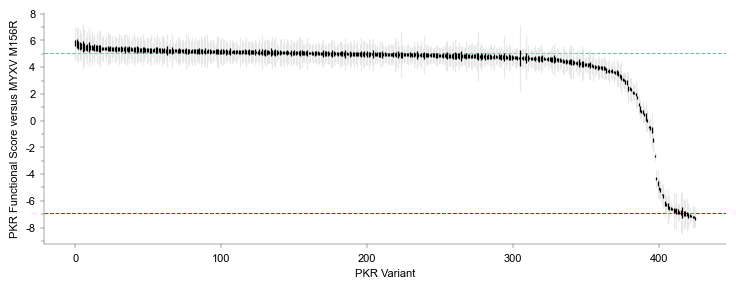

Scatter Plot with Standard Deviation Bars


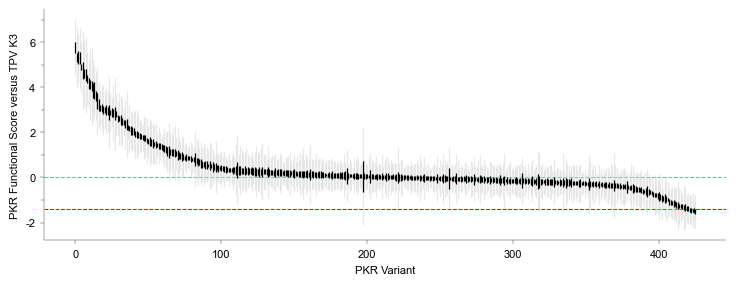

In [15]:
# wide plots with std and se
# NEED TO REDO SORT ORDER AFTER REMOVING WT AND NONSENSE VARIANTS
k3_conditions = ['K3Δ58', 'RCVZ vIF2α', 'VACV K3', 'VARV C3','MYXV M156R','TPV K3']

for k3 in k3_conditions:
    # plot parameters
    width_in = 8.8 #2.3
    height_in = 3 #2
    font_size = 8
    font = 'Arial'
    stroke = .25
    tick_len = 3
    alpha_val = .2
    marker_diameter = 3 # 3
    #ymin = -5
    #ymax=5.9

    font = {'family': font, 'size': font_size}
    plt.rc('font', **font)
    plt.rc('lines', linewidth=stroke)
    plt.figure(figsize=(width_in, height_in)) # save size

    temp_df = df.query('k3 == @k3')

    hline_wt = temp_df.query('pkr_type == "WT"')['auc_mean'].values[0]
    hline_non = temp_df.query('pkr_type == "Nonsense"')['auc_mean'].values[0]

    temp_df.query('pkr_type == "Variant"', inplace=True)
    temp_df.sort_values(by=['auc_mean'], ascending=False, inplace=True)
    #temp_df.sort_values(by=, ascending=True, inplace=True)
    temp_df.reset_index(drop=True, inplace=True)
    
    # Plot elements
    for i, row in temp_df.query('pkr_type == "Variant"').iterrows():
        #plt.errorbar(i, row['auc_mean'], yerr=row['auc_std'], fmt='-', color='gray', capsize=0, alpha=0.5, zorder=1)
        plt.errorbar(i, row['auc_mean'], yerr=row['auc_std'], fmt='-', color='lightgray', capsize=0, zorder=1, alpha=.5, elinewidth=.9)
        #plt.errorbar(i, row['auc_mean'], yerr=row['auc_sem'], fmt='-', color='black', capsize=0, alpha=1, zorder=2)
        plt.errorbar(i, row['auc_mean'], yerr=row['auc_sem'], fmt='-', c='black', capsize=0, zorder=2, elinewidth=.9)
        #plt.scatter(i,row['auc_mean'], c=row['region_color'], alpha=1, zorder=3, s=2)
    
    # y tick limits
    if k3 == "K3L-Null":
        plt.ylim(-8, 8)
    elif k3 == "K3L-WT":
        plt.ylim(-6, 10)
    elif k3 == "K3L-H47R":
        plt.ylim(-4, 12)

    # modify plot spines
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)

    # Set major ticks at even numbers and label as integers
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(2))
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

    # Show minor ticks for every integer
    plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))
    
    # Set major tick length
    ax.tick_params(axis='both', direction='out', length=tick_len, width=stroke)
    plt.gca().yaxis.set_tick_params(width=stroke, which='both', direction='out')

    # pkr wt
    plt.axhline(y=hline_wt, color='#6dc091', linestyle='--', linewidth=.75, zorder=0)

    # pkr nonsense  
    plt.axhline(y=hline_non, color='red', linestyle='--', linewidth=.75, zorder=0)
    
    # Add labels and title
    plt.xlabel('PKR Variant')
    plt.ylabel(f'PKR Functional Score versus {k3}')
    print(f'Scatter Plot with Standard Deviation Bars')
    
    # Show plot
    plt.show()

    fig = ax.get_figure()

    # save plot
    plot_name = f'wide-score-curve_{k3}.svg'
    output_file = os.path.join(save_dir, plot_name)
    fig.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

In [18]:
# previous score curves
input_file = '../../data/prev-k3-data/combined_variant-reads_240305.csv'
df1 = pd.read_csv(input_file)
df1.k3.replace('K3L-Null', 'K3Δ58', inplace=True)
df1.k3.replace('K3L-WT', 'VACV K3', inplace=True)
df1['replicate'] = 'Replicate 240305'

,k3,pkr,pkr_bc,0hr,12hr,16hr,20hr,0hr_norm,12hr_norm,16hr_norm,...,var_cat,isr_kinase_conservation,elde_primate_positive_selection,vertebrate_positive_selection,pkr_conservation,jaquet_primate_positive_selection,vert_sele_analysis,elde_primate_sele_analysis,jaquet_primate_sele_analysis,replicate
0,K3Δ58,PKR-A488D,AGCAGAACAGCTAAAAAAATTAGAGC,513.0,127.0,96.0,85.0,0.000140,0.000048,0.000040,...,Negative Charge,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Replicate 240305
1,K3Δ58,PKR-A488D,ATAGCAACTAACAATCTTATTATCCA,548.0,123.0,103.0,85.0,0.000150,0.000046,0.000043,...,Negative Charge,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Replicate 240305
2,K3Δ58,PKR-A488D,CAATAAATAGAGAATGCTTTTACAAC,60.0,6.0,15.0,10.0,0.000016,0.000002,0.000006,...,Negative Charge,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Replicate 240305
3,K3Δ58,PKR-A488D,CTTATAAAAATTAAGGGCTTTTACAT,440.0,117.0,91.0,90.0,0.000120,0.000044,0.000038,...,Negative Charge,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Replicate 240305
4,K3Δ58,PKR-A488D,GCCGCAAAACTTAACCAATTTTAAAT,180.0,52.0,22.0,32.0,0.000049,0.000020,0.000009,...,Negative Charge,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Vertebrate Positive Selection,NaN,NaN,Replicate 240305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61269,SUI2,PKR-Y454S,TACGAAACGGTTAACCAATTTGTTAC,79.0,140.0,105.0,143.0,0.000027,0.000031,0.000028,...,Polar-Neutral,Conserved Kinase Residue,NaN,NaN,Conserved PKR Residue,NaN,Conserved PKR Residue,Conserved PKR Residue,Conserved PKR Residue,Replicate 240305
61270,SUI2,PKR-Y454S,TATGAAAATTTAAAATTTATTCATTA,233.0,343.0,316.0,339.0,0.000079,0.000075,0.000083,...,Polar-Neutral,Conserved Kinase Residue,NaN,NaN,Conserved PKR Residue,NaN,Conserved PKR Residue,Conserved PKR Residue,Conserved PKR Residue,Replicate 240305
61271,SUI2,PKR-Y454S,TCCGGAACGAGGAAGGCCATTAAACA,434.0,628.0,670.0,603.0,0.000148,0.000137,0.000177,...,Polar-Neutral,Conserved Kinase Residue,NaN,NaN,Conserved PKR Residue,NaN,Conserved PKR Residue,Conserved PKR Residue,Conserved PKR Residue,Replicate 240305
61272,SUI2,PKR-Y454S,TGTACAAAACACAACACGATTAATGA,525.0,643.0,573.0,553.0,0.000179,0.000140,0.000151,...,Polar-Neutral,Conserved Kinase Residue,NaN,NaN,Conserved PKR Residue,NaN,Conserved PKR Residue,Conserved PKR Residue,Conserved PKR Residue,Replicate 240305
